In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/EDA/featured_dataset/train_featured.csv')
val_df   = pd.read_csv('/Users/deannalakshman/Desktop/IIT/YEAR 2/SEM 2/DSPLC/Coursework technical/EDA/featured_dataset/val_featured.csv')

# Combine for full historical analysis
df = pd.concat([train_df, val_df], ignore_index=True)

print('Combined shape:', df.shape)

Combined shape: (30248, 37)


In [2]:
# Convert date columns to datetime
date_cols = ['Expected_checkin', 'Expected_checkout', 'Booking_date']

for d in [df, train_df]:
    for col in date_cols:
        d[col] = pd.to_datetime(d[col], errors='coerce')

In [3]:
# Calculate stay duration and potential revenue
for d in [df, train_df]:
    d['Stay_Duration']    = (d['Expected_checkout'] - d['Expected_checkin']).dt.days
    d['Stay_Duration']    = d['Stay_Duration'].apply(lambda x: max(x, 1))
    d['Potential_Revenue'] = d['Room_Rate'] * d['Stay_Duration'] * (1 - d['Discount_Rate'] / 100)
    d['Lead_Time']         = (d['Expected_checkin'] - d['Booking_date']).dt.days

print('Potential Revenue stats:')
print(df['Potential_Revenue'].describe())

Potential Revenue stats:
count    30248.000000
mean       280.232582
std        174.450533
min         60.000000
25%        150.000000
50%        217.000000
75%        378.000000
max       1000.000000
Name: Potential_Revenue, dtype: float64


In [4]:
# simplified status mapping

status_map = {
    'Check-Out' : 'Gained',
    'Cancelled'  : 'Lost',
    'No-Show'   : 'Lost'
}

for d in [df, train_df]:
    d['Simplified_Status'] = d['Reservation_Status'].map(status_map)

# Verify — should show no NaN
print(df['Simplified_Status'].value_counts())
print('NaN in Simplified_Status:', df['Simplified_Status'].isnull().sum())

Simplified_Status
Gained    22850
Lost       7398
Name: count, dtype: int64
NaN in Simplified_Status: 0


In [5]:
# Revenue Gained d Lost columns

for d in [df, train_df]:
    d['Is_Loss']       = d['Simplified_Status'] == 'Lost'
    d['Revenue_Loss']  = np.where(d['Is_Loss'], d['Potential_Revenue'], 0)
    d['Revenue_Gained']= np.where(~d['Is_Loss'], d['Potential_Revenue'], 0)

total_gained = df['Revenue_Gained'].sum()
total_lost   = df['Revenue_Loss'].sum()

print(f'Total Revenue Gained : ${total_gained:,.2f}')
print(f'Total Revenue Lost   : ${total_lost:,.2f}')
print(f'Loss Percentage      : {(total_lost / (total_gained + total_lost)) * 100:.2f}%')

Total Revenue Gained : $6,410,427.40
Total Revenue Lost   : $2,066,047.75
Loss Percentage      : 24.37%


In [6]:
#  Feature Engineering: Income group, Room Category, Stay Bucket

# Income Group
income_map = {
    '<25K'       : 'Low Income',
    '25K --50K'  : 'Middle Income',
    '50K -- 100K': 'Upper Middle',
    '>100K'      : 'High Income'
}
for d in [df, train_df]:
    d['Income_Group'] = d['Income'].map(income_map)

# Room Category
for d in [df, train_df]:
    d['Room_Category'] = pd.cut(d['Room_Rate'],
                                bins=[0, 100, 200, 300, 500],
                                labels=['Budget', 'Standard', 'Premium', 'Luxury'])

# Stay Bucket
for d in [df, train_df]:
    d['Stay_Bucket'] = pd.cut(d['Stay_Duration'],
                              bins=[0, 2, 5, 100],
                              labels=['1-2 nights', '3-5 nights', '6+ nights'])

print('Income Group:', train_df['Income_Group'].value_counts().to_dict())
print('Room Category:', train_df['Room_Category'].value_counts().to_dict())

Income Group: {'Upper Middle': 7936, 'Middle Income': 7870, 'Low Income': 7739, 'High Income': 3954}
Room Category: {'Standard': 18039, 'Premium': 9265, 'Budget': 195, 'Luxury': 0}


## Chart 1: Overall Revenue Pie Chart

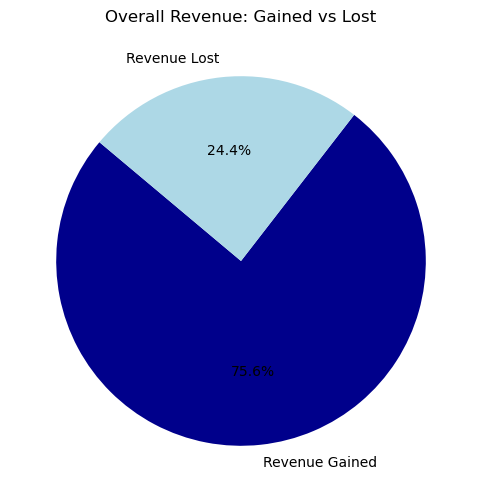

In [7]:
plt.figure(figsize=(8, 6))
plt.pie([total_gained, total_lost],
        labels=['Revenue Gained', 'Revenue Lost'],
        autopct='%1.1f%%',
        startangle=140,
        colors=['darkblue', 'lightblue'])
plt.title('Overall Revenue: Gained vs Lost')
plt.show()

## Chart 2: Revenue Loss by Hotel Type

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/1313080013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hotel_loss, x='Hotel_Type', y='Revenue_Loss', palette='Blues_r')


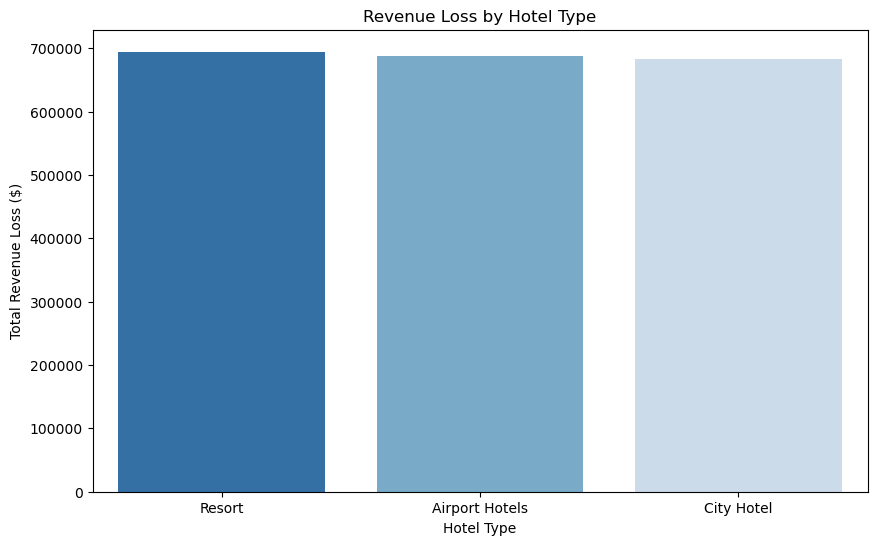

In [8]:
hotel_loss = df.groupby('Hotel_Type')['Revenue_Loss'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=hotel_loss, x='Hotel_Type', y='Revenue_Loss', palette='Blues_r')
plt.title('Revenue Loss by Hotel Type')
plt.ylabel('Total Revenue Loss ($)')
plt.xlabel('Hotel Type')
plt.show()

## Chart 3: Revenue Loss by Deposit Type

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/954184103.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=deposit_loss, x='Deposit_type', y='Revenue_Loss', palette='Blues_r')


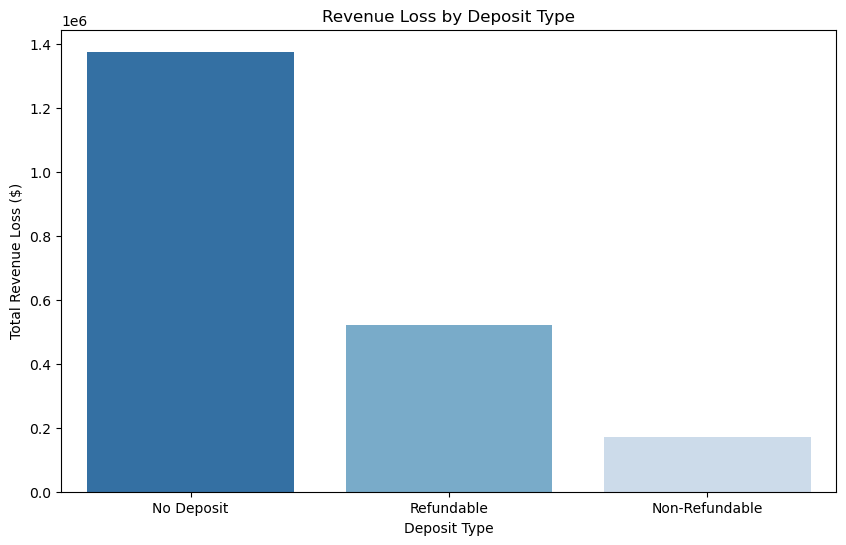

In [9]:
deposit_loss = df.groupby('Deposit_type')['Revenue_Loss'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=deposit_loss, x='Deposit_type', y='Revenue_Loss', palette='Blues_r')
plt.title('Revenue Loss by Deposit Type')
plt.ylabel('Total Revenue Loss ($)')
plt.xlabel('Deposit Type')
plt.show()

## Chart 4: Revenue Loss by Booking Channel

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/48799770.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_loss, x='Booking_channel', y='Revenue_Loss', palette='Blues_r')


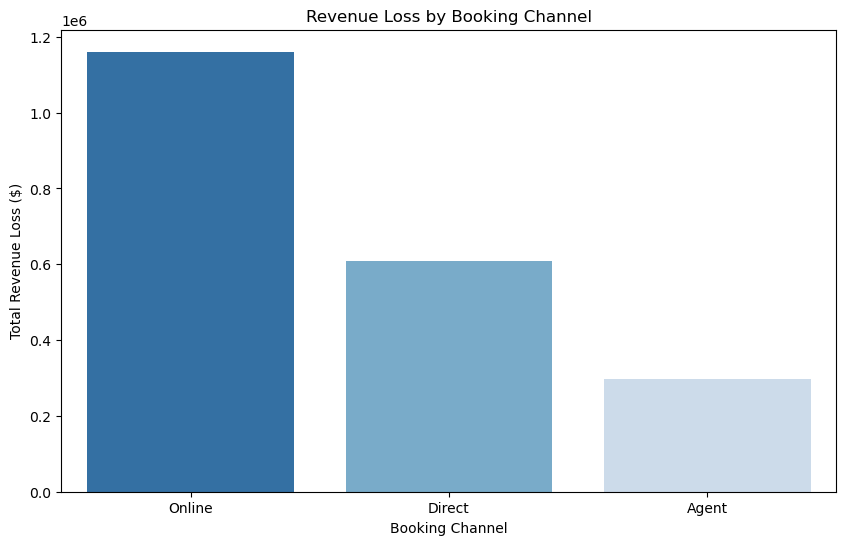

In [10]:
channel_loss = df.groupby('Booking_channel')['Revenue_Loss'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=channel_loss, x='Booking_channel', y='Revenue_Loss', palette='Blues_r')
plt.title('Revenue Loss by Booking Channel')
plt.ylabel('Total Revenue Loss ($)')
plt.xlabel('Booking Channel')
plt.show()

## Chart 5: Revenue Loss by Region

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/3184631908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_loss, x='Country_region', y='Revenue_Loss', palette='Blues_r')


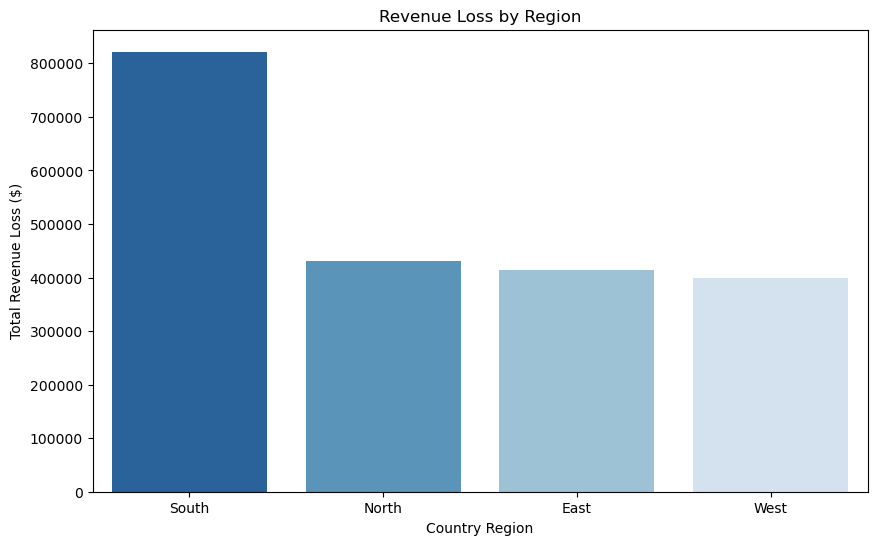

In [11]:
region_loss = df.groupby('Country_region')['Revenue_Loss'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=region_loss, x='Country_region', y='Revenue_Loss', palette='Blues_r')
plt.title('Revenue Loss by Region')
plt.ylabel('Total Revenue Loss ($)')
plt.xlabel('Country Region')
plt.xticks(rotation=0)
plt.show()

## Chart 6: Revenue Loss by Income Group

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/1227045125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=income_loss, x='Income_Group', y='Revenue_Loss', palette='Blues_r')


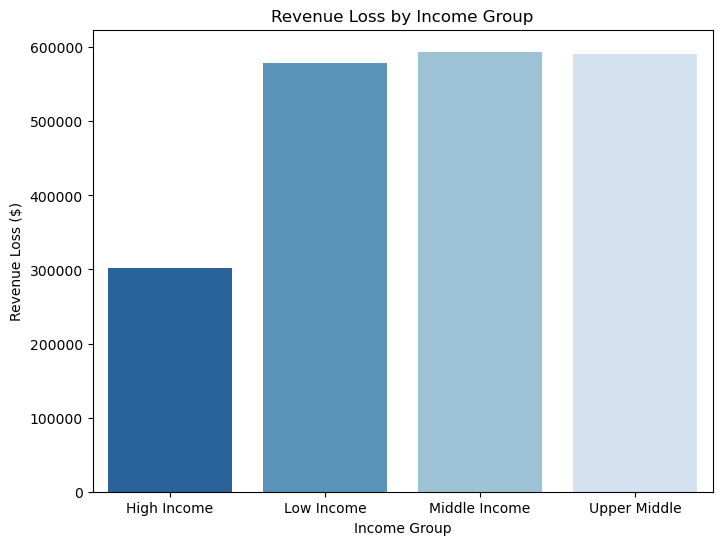

In [12]:
income_loss = df.groupby('Income_Group')['Revenue_Loss'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=income_loss, x='Income_Group', y='Revenue_Loss', palette='Blues_r')
plt.title('Revenue Loss by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Revenue Loss ($)')
plt.show()

## Chart 7: Revenue Loss by Room Category

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/298255970.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  room_loss = df.groupby('Room_Category')['Revenue_Loss'].sum().reset_index()
/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/298255970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=room_loss, x='Room_Category', y='Revenue_Loss', palette='Blues_r')


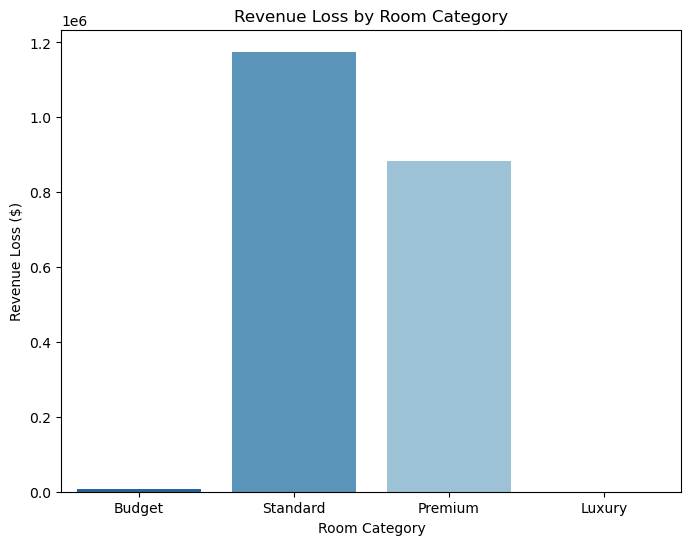

In [13]:
room_loss = df.groupby('Room_Category')['Revenue_Loss'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=room_loss, x='Room_Category', y='Revenue_Loss', palette='Blues_r')
plt.title('Revenue Loss by Room Category')
plt.xlabel('Room Category')
plt.ylabel('Revenue Loss ($)')
plt.show()

## Chart 8: Monthly Revenue Loss Trend

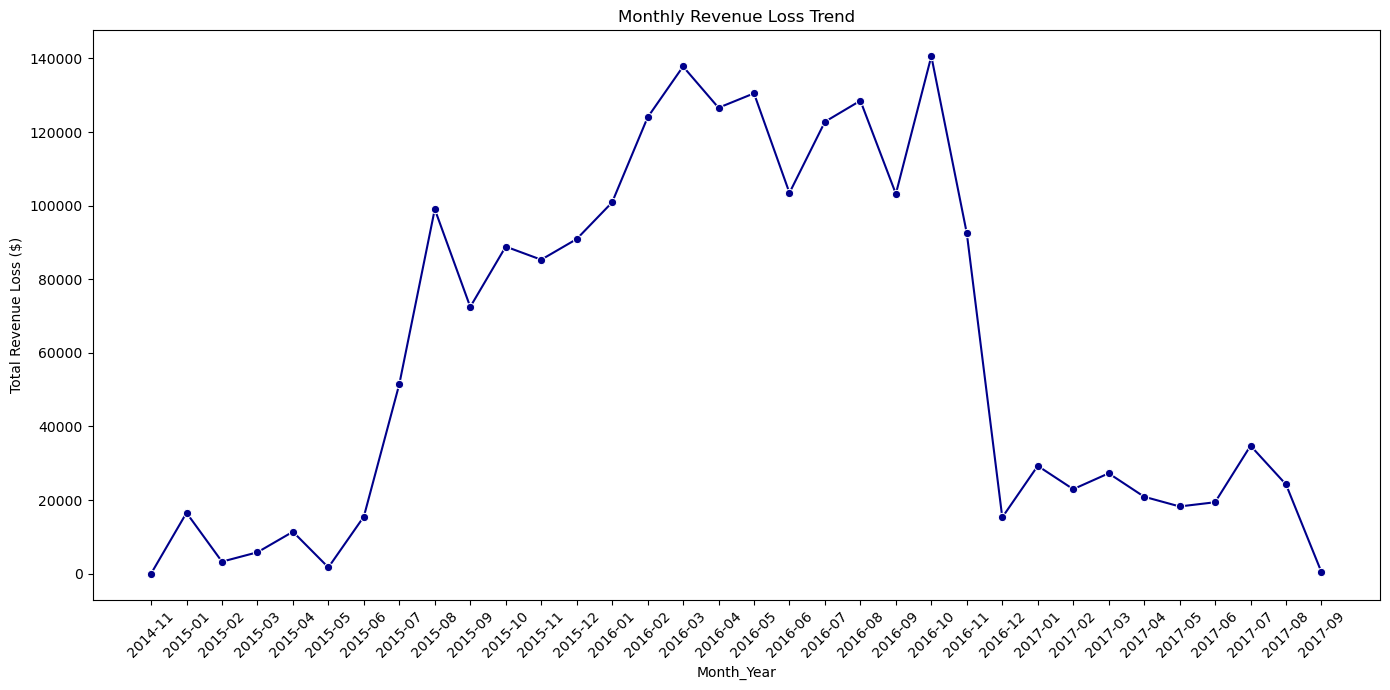

In [14]:
df['Month_Year'] = df['Expected_checkin'].dt.to_period('M').astype(str)
monthly_loss = df.groupby('Month_Year')['Revenue_Loss'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_loss, x='Month_Year', y='Revenue_Loss', marker='o', color='darkblue')
plt.title('Monthly Revenue Loss Trend')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue Loss ($)')
plt.tight_layout()
plt.show()

## Chart 9: Lead Time Distribution (Gained vs Lost)

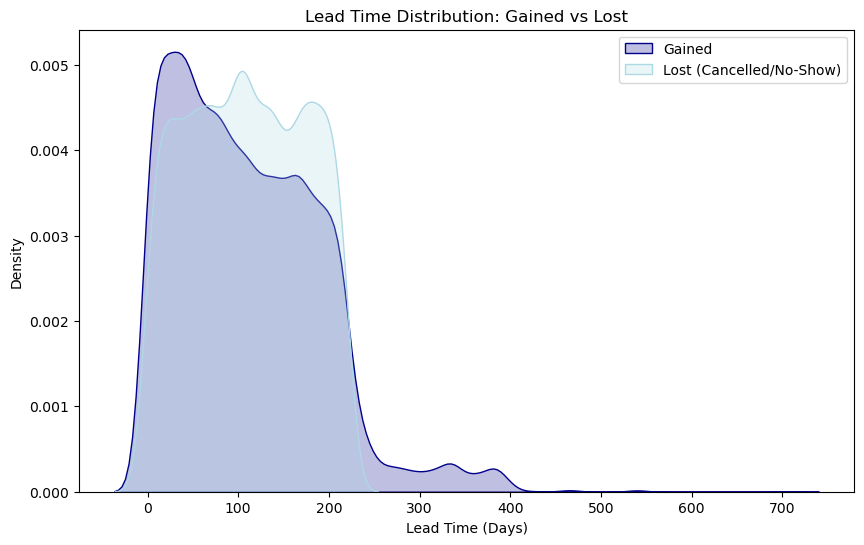

In [15]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Simplified_Status'] == 'Gained'], x='Lead_Time',
            label='Gained', color='darkblue', fill=True)
sns.kdeplot(data=df[df['Simplified_Status'] == 'Lost'], x='Lead_Time',
            label='Lost (Cancelled/No-Show)', color='lightblue', fill=True)
plt.title('Lead Time Distribution: Gained vs Lost')
plt.xlabel('Lead Time (Days)')
plt.legend()
plt.show()

## Chart 10: Revenue by Booking Channel and Status

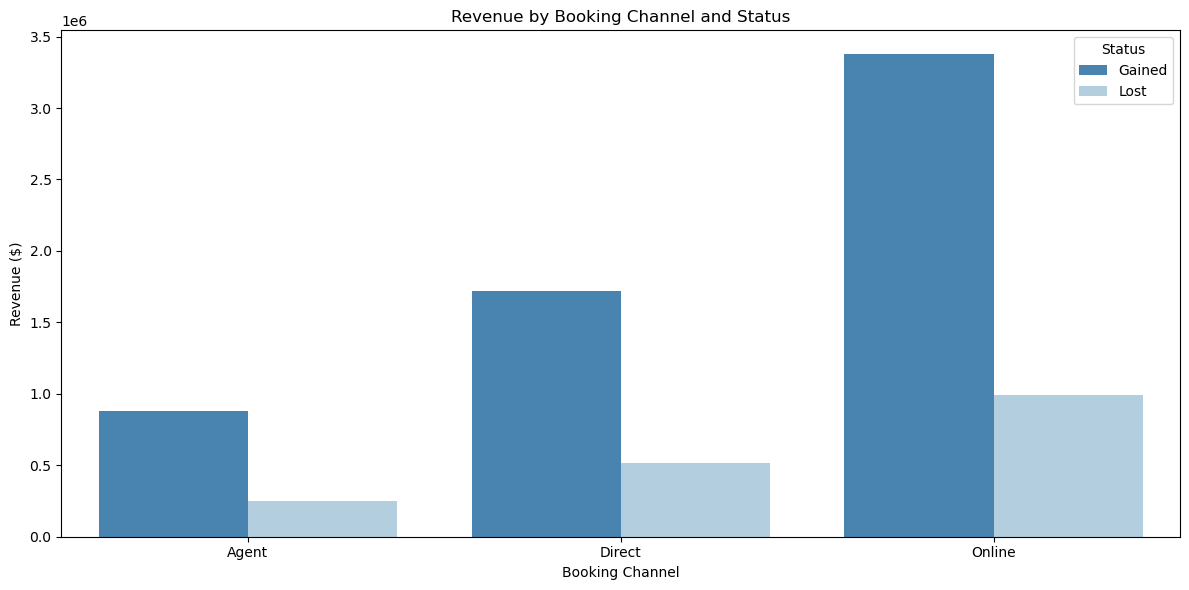

In [16]:
channel_status = train_df.groupby(['Booking_channel', 'Simplified_Status'])['Potential_Revenue'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=channel_status, x='Booking_channel', y='Potential_Revenue',
            hue='Simplified_Status', palette='Blues_r')
plt.title('Revenue by Booking Channel and Status')
plt.xlabel('Booking Channel')
plt.ylabel('Revenue ($)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

## Chart 11: Revenue by Length of Stay and Status

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/3690555445.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stay_loss = train_df.groupby(['Stay_Bucket', 'Simplified_Status'])['Potential_Revenue'].sum().reset_index()


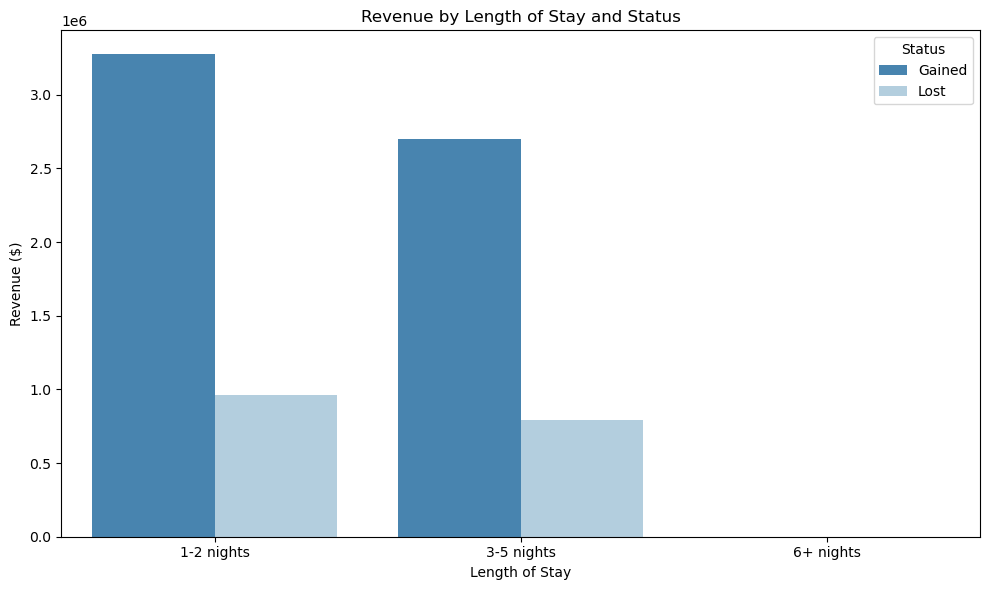

In [17]:
stay_loss = train_df.groupby(['Stay_Bucket', 'Simplified_Status'])['Potential_Revenue'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=stay_loss, x='Stay_Bucket', y='Potential_Revenue',
            hue='Simplified_Status', palette='Blues_r')
plt.title('Revenue by Length of Stay and Status')
plt.xlabel('Length of Stay')
plt.ylabel('Revenue ($)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

## Chart 12: Revenue by Monthly and status

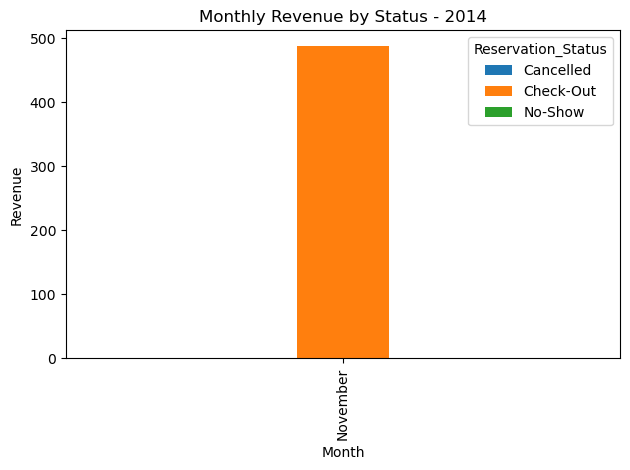

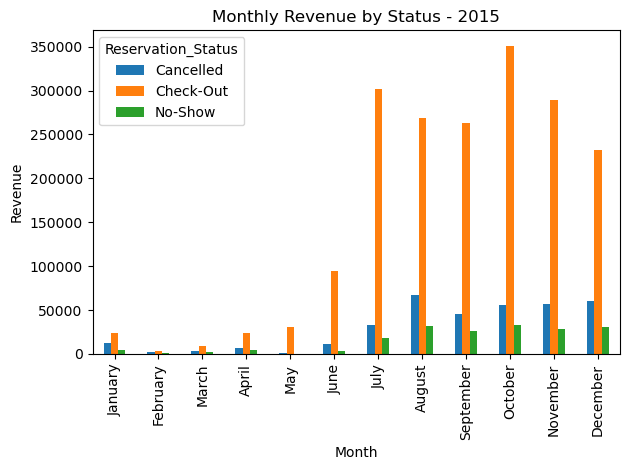

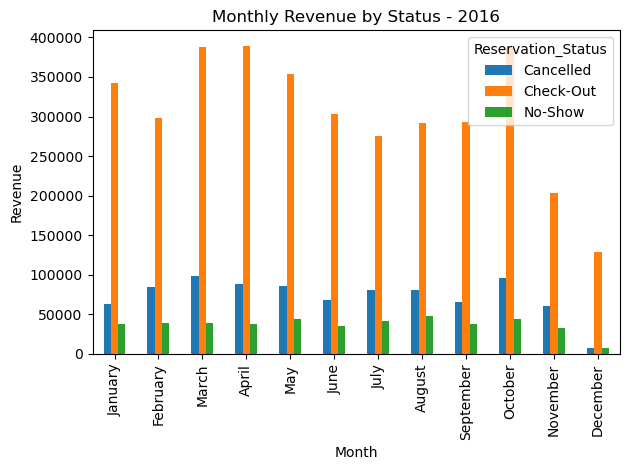

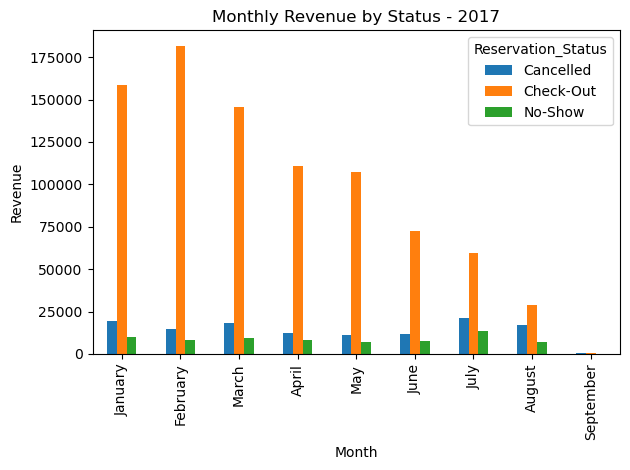

In [ ]:
# Create Year and Month separately
df['Year'] = df['Expected_checkin'].dt.year
df['Month'] = df['Expected_checkin'].dt.strftime('%B')  # Full month name

# Optional: to keep months in calendar order when plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Group data
monthly_status = df.groupby(['Year', 'Month', 'Reservation_Status'])['Potential_Revenue'].sum().unstack().fillna(0)

# Reindex months so they appear in calendar order
monthly_status = monthly_status.reindex(month_order, level=1)

# Plot each year separately
for year in monthly_status.index.get_level_values(0).unique():
    data = monthly_status.loc[year]
    
    data.plot(kind='bar')
    plt.title(f"Monthly Revenue by Status - {year}")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.xticks(rotation=90)
    
    plt.tight_layout()
    plt.show()

## Chart 13: Revenue By Room category and Booking Channel

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/3345055765.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  room_channel = train_df.groupby(['Room_Category','Booking_channel'])['Potential_Revenue'].sum().reset_index()


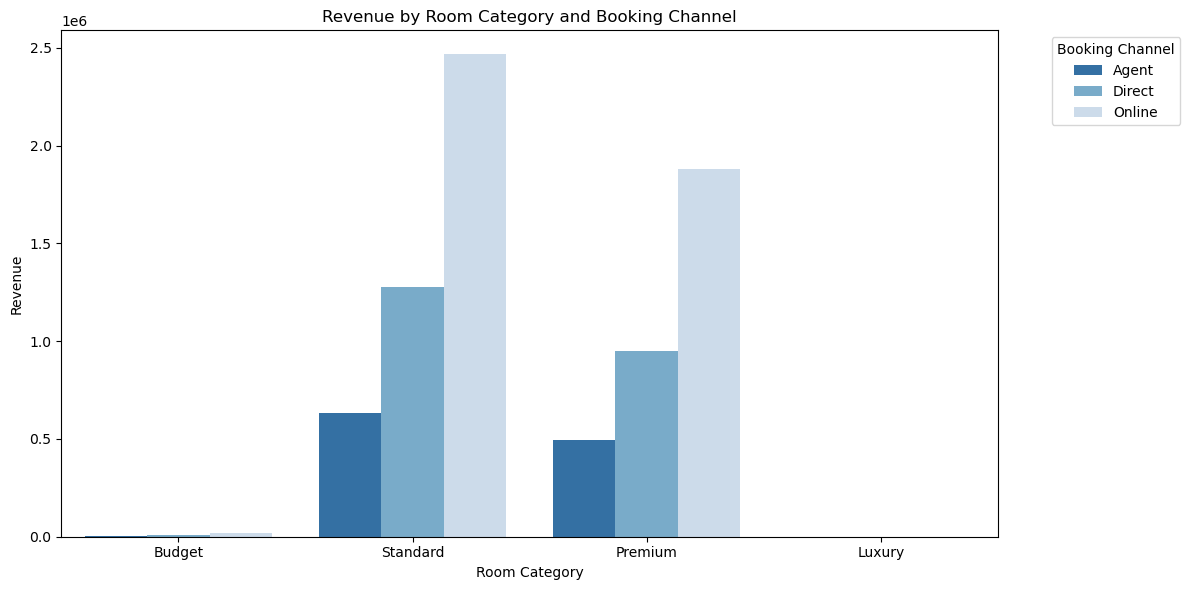

In [20]:
room_channel = train_df.groupby(['Room_Category','Booking_channel'])['Potential_Revenue'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=room_channel, x='Room_Category', y='Potential_Revenue', hue='Booking_channel', palette='Blues_r')
plt.title('Revenue by Room Category and Booking Channel')
plt.xlabel('Room Category')
plt.ylabel('Revenue')
plt.legend(title='Booking Channel', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## Chart 14: Revenue By Income Group and Booking Channel

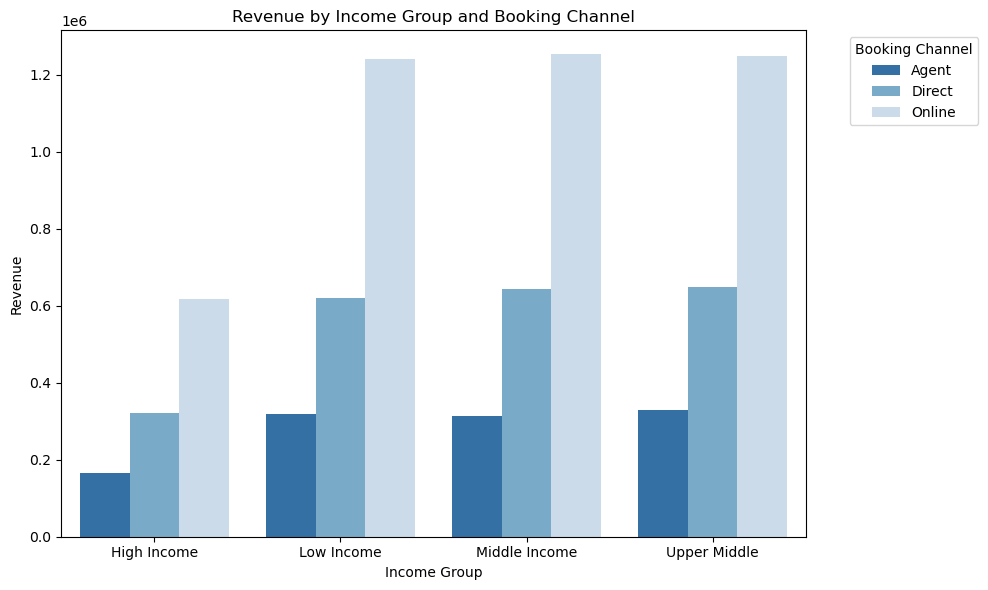

In [21]:
income_channel = train_df.groupby(['Income_Group','Booking_channel'])['Potential_Revenue'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=income_channel, x='Income_Group', y='Potential_Revenue', hue='Booking_channel', palette='Blues_r')
plt.title('Revenue by Income Group and Booking Channel')
plt.xlabel('Income Group')
plt.ylabel('Revenue')
plt.legend(title='Booking Channel', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## Chart 15: Revenue by Income Group and Reservation Status

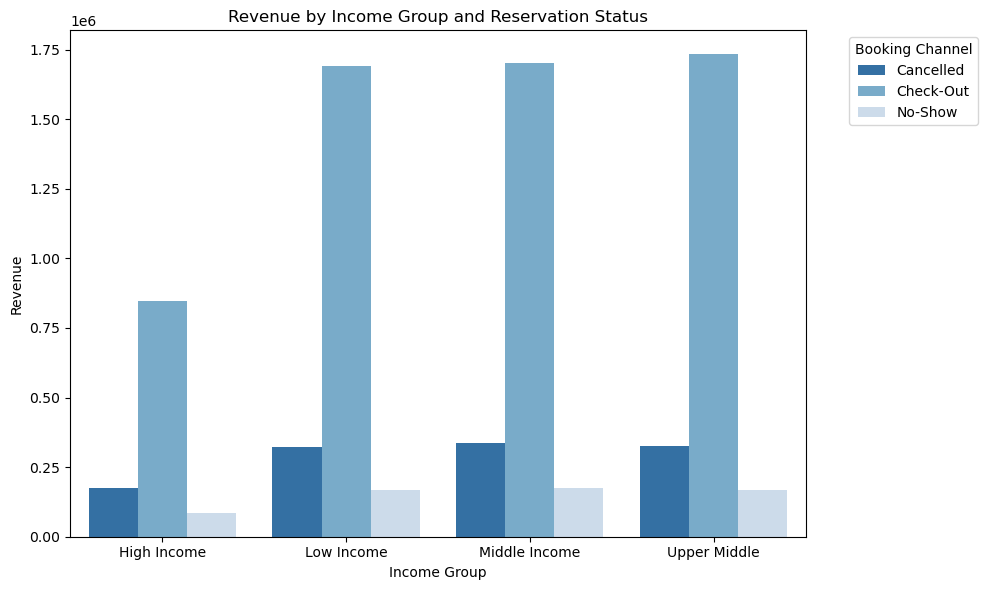

In [22]:
income_channel = train_df.groupby(['Income_Group','Reservation_Status'])['Potential_Revenue'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=income_channel, x='Income_Group', y='Potential_Revenue', hue='Reservation_Status', palette='Blues_r')
plt.title('Revenue by Income Group and Reservation Status')
plt.xlabel('Income Group')
plt.ylabel('Revenue')
plt.legend(title='Booking Channel', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## Revenue by Check-in Day and Room Category

/var/folders/6t/jnkw6zz543q4vx7jvts4bb8h0000gn/T/ipykernel_23707/528137411.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_room_loss = train_df.groupby(['Checkin_Day','Room_Category'])['Potential_Revenue'].sum().reset_index()


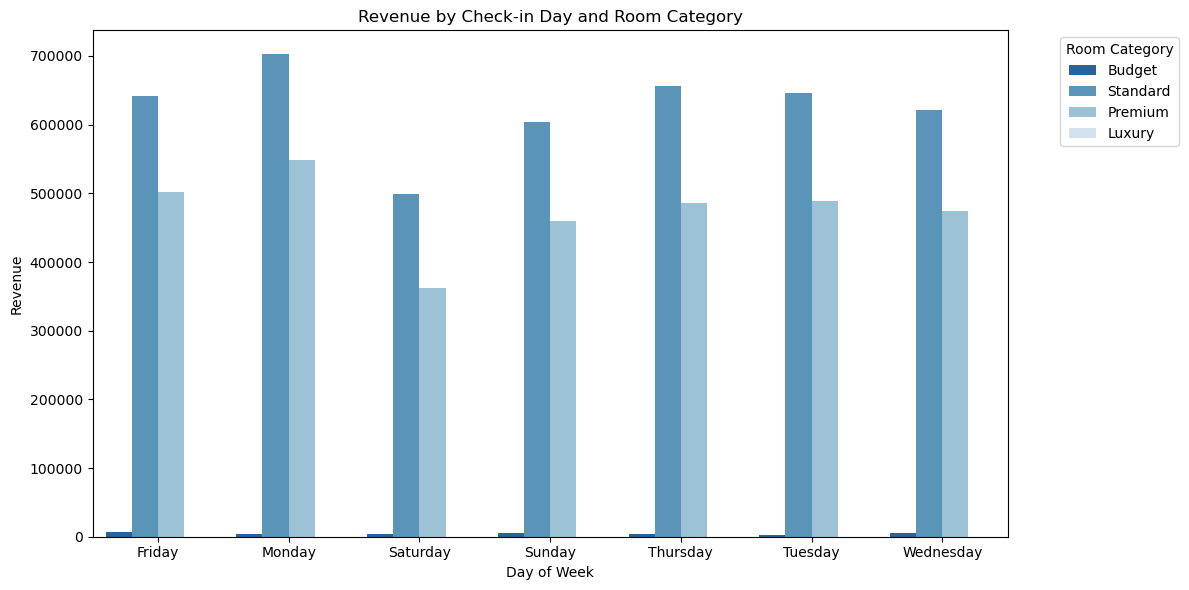

In [23]:
train_df['Checkin_Day'] = train_df['Expected_checkin'].dt.day_name()

day_room_loss = train_df.groupby(['Checkin_Day','Room_Category'])['Potential_Revenue'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=day_room_loss, x='Checkin_Day', y='Potential_Revenue', hue='Room_Category', palette='Blues_r')
plt.title('Revenue by Check-in Day and Room Category')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.legend(title='Room Category', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## HUBIFI Revenue Breakdown Summary

In [19]:
df['Gross_Potential']           = df['Stay_Duration'] * df['Room_Rate']
df['Actual_After_Discount']     = df['Gross_Potential'] * (1 - df['Discount_Rate'] / 100)
df['Revenue_Leakage_Discounts'] = df['Gross_Potential'] - df['Actual_After_Discount']

is_lost = df['Simplified_Status'] == 'Lost'
df['Revenue_Loss_Churn'] = np.where(is_lost, df['Actual_After_Discount'], 0)
df['Realized_Revenue']   = np.where(~is_lost, df['Actual_After_Discount'], 0)

print('--- REVENUE ANALYSIS REPORT ---')
print(f"Total Potential Revenue (Gross)    : ${df['Gross_Potential'].sum():,.2f}")
print(f"Revenue Leakage (Discounts)        : ${df['Revenue_Leakage_Discounts'].sum():,.2f}")
print(f"Revenue Loss (Cancellations/No-Show): ${df['Revenue_Loss_Churn'].sum():,.2f}")
print(f"----------------------------------------------")
print(f"Final Realized Revenue             : ${df['Realized_Revenue'].sum():,.2f}")

--- REVENUE ANALYSIS REPORT ---
Total Potential Revenue (Gross)    : $9,688,218.00
Revenue Leakage (Discounts)        : $1,211,742.85
Revenue Loss (Cancellations/No-Show): $2,066,047.75
----------------------------------------------
Final Realized Revenue             : $6,410,427.40
